In [3]:
import bayesflow as bf
import numpy as np


import rpy2.robjects as robjects
import numpy as np

In [4]:
import rpy2.robjects as robjects
import numpy as np

# Load data from R
robjects.r('load("SpainPROV_CerebrovascularDiseases.Rdata")')

Rs = robjects.r('as.matrix(Rs)')


Rs_numpy = np.array(Rs)


In [6]:
# Compute eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(Rs_numpy)

# Compute covariance matrix Q
Q = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T  # Q = V * D * V.T

def process_Q_full(Q, tol=1e-10):
    # Perform eigen decomposition of Q
    eigenvalues, eigenvectors = np.linalg.eigh(Q)
    
    # Print and handle near-zero eigenvalues
    near_zero_mask = (np.abs(eigenvalues) < tol)
    if np.any(near_zero_mask):
        print("Detected near-zero eigenvalues:", eigenvalues[near_zero_mask])
        print("Setting the scaling factors for these eigenvalues to 0.")
    
    # Process all eigenvalues: if eigenvalue < tol, set the corresponding scaling factor to 0; otherwise, set it to 1/sqrt(λ)
    scaling = np.where(np.abs(eigenvalues) < tol, 0.0, 1/np.sqrt(eigenvalues))
    
    # Construct transformation matrix L while preserving all 47 eigenvectors
    L = eigenvectors @ np.diag(scaling)
    
    # Check if L @ L.T is approximately equal to Q^{-1} (it may degenerate for non-positive definite cases)
    M = L @ L.T
    eig_M = np.linalg.eigvalsh(M)
    if np.all(eig_M > -tol):  # Consider numerical errors
        print("Output matrix L @ L.T is positive semi-definite.")
    else:
        print("Warning: Output matrix L @ L.T has significant negative eigenvalues:", eig_M)
    
    return L


L = process_Q_full(Q)


Detected near-zero eigenvalues: [-1.6040939e-16]
Setting the scaling factors for these eigenvalues to 0.


/var/folders/xh/6yy1qtv504b1yv27rltr5cdc0000gn/T/ipykernel_27637/2568433336.py:18: RuntimeWarning: invalid value encountered in sqrt
  scaling = np.where(np.abs(eigenvalues) < tol, 0.0, 1/np.sqrt(eigenvalues))


Output matrix L @ L.T is positive semi-definite.


In [ ]:
# ============ 1) Define global variables Q, mu, etc. ============
mu = np.zeros(47, dtype=np.float32)

# ============ 2) Define prior =============
def prior(low=1.0, high=2.0):
    # 1. Generate tau (scalar), tau ~ Uniform(low, high)
    tau_val = np.random.uniform(low=low, high=high)
    tau = np.float32(tau_val)
    
    # 2. Generate a standard normal random vector z with the same dimension as L's columns (currently 47)
    z = np.random.randn(L.shape[1]).astype(np.float32)
    
    # 3. Transform z using L to obtain a sample from N(0, Q^{-1}),
    #    then scale by 1/sqrt(tau) to obtain a sample from N(0, (1/tau) Q^{-1}), and finally add mu
    log_risk_samples = mu + (1/np.sqrt(tau)) * (L @ z)
    
    # 4. Concatenate tau to obtain the parameter vector theta
    theta = np.concatenate([log_risk_samples, [tau]]).astype(np.float32)
    return theta

# ============ 3) Define simulator =============
def simulator(theta, n_obs=100):
    # Here, theta is (48,)
    log_risk = theta[:47]
    # tau = theta[-1]  # If tau is needed later
    lam = np.exp(log_risk)

    # Sample (n_obs, 47)
    obs = np.random.poisson(lam=lam, size=(n_obs, 47)).astype(np.float32)

    return obs

# ============ 4) Construct Bayesian Flow's GenerativeModel =========
generative_model = bf.simulation.GenerativeModel(
    prior=prior,
    simulator=simulator,
    name="Generative Model: Training",
    simulator_is_batched=False  
)


INFO:root:Performing 2 pilot runs with the Generative Model: Training model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 48)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 100, 47)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [11]:
summary_net = bf.networks.SetTransformer(input_dim=47)
inference_net = bf.networks.InvertibleNetwork(num_params=48, num_coupling_layers=48)
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net, summary_loss_fun="MMD")
trainer = bf.trainers.Trainer(generative_model=generative_model, amortizer=amortizer, memory=True)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [12]:
losses = trainer.train_online(epochs=10, iterations_per_epoch=500, batch_size=32)

Training epoch 1: 100%|██████████| 500/500 [01:38<00:00,  5.06it/s, Epoch: 1, Iter: 500,Loss: 41.207,W.Decay: 3.268,Avg.Loss: 2229738143744.000,Avg.W.Decay: 3.321,LR: 4.93E-09]             


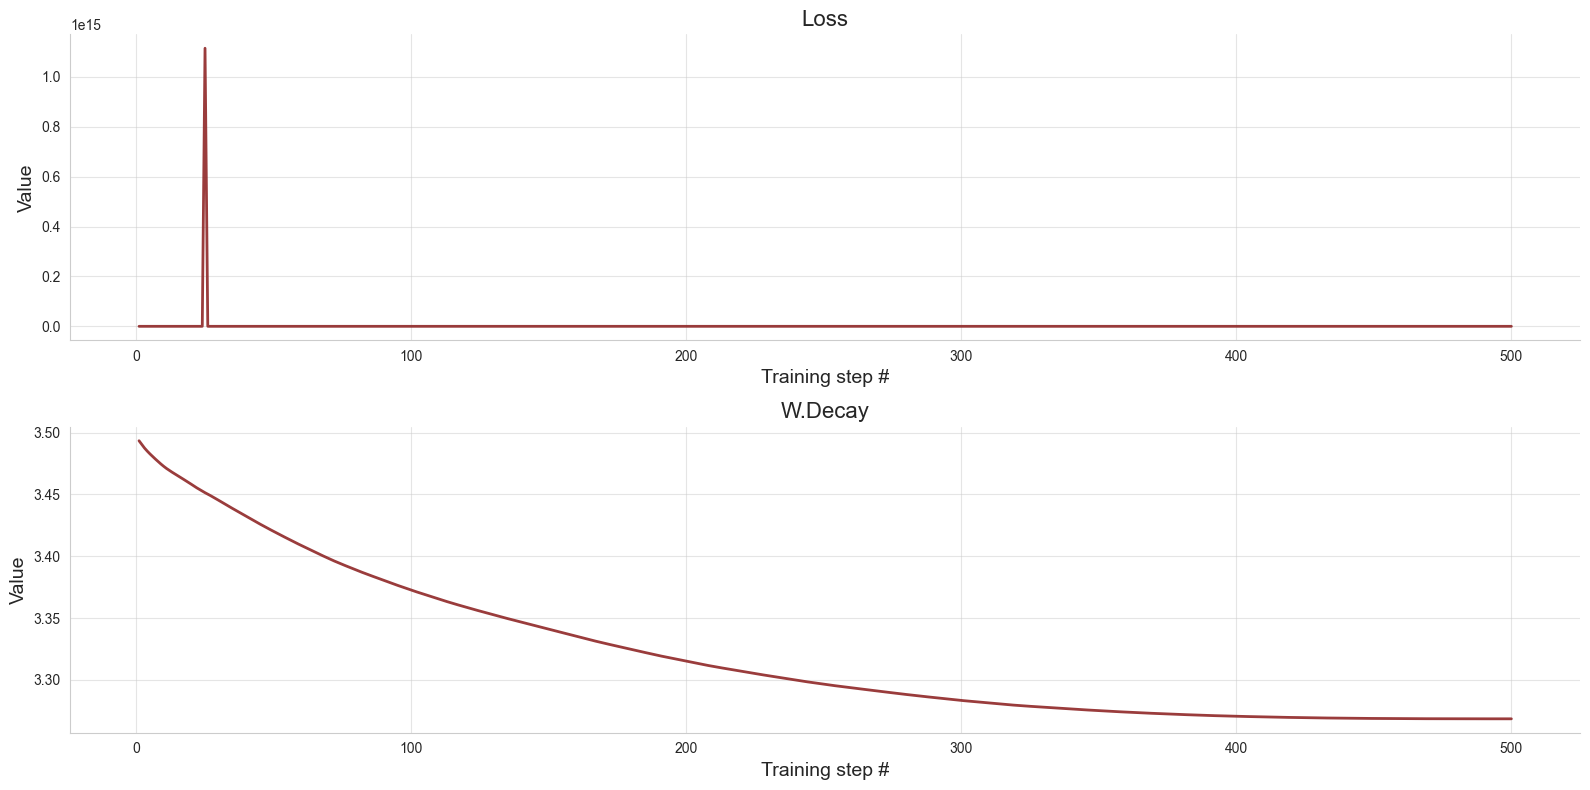

In [13]:
fig = bf.diagnostics.plot_losses(losses)

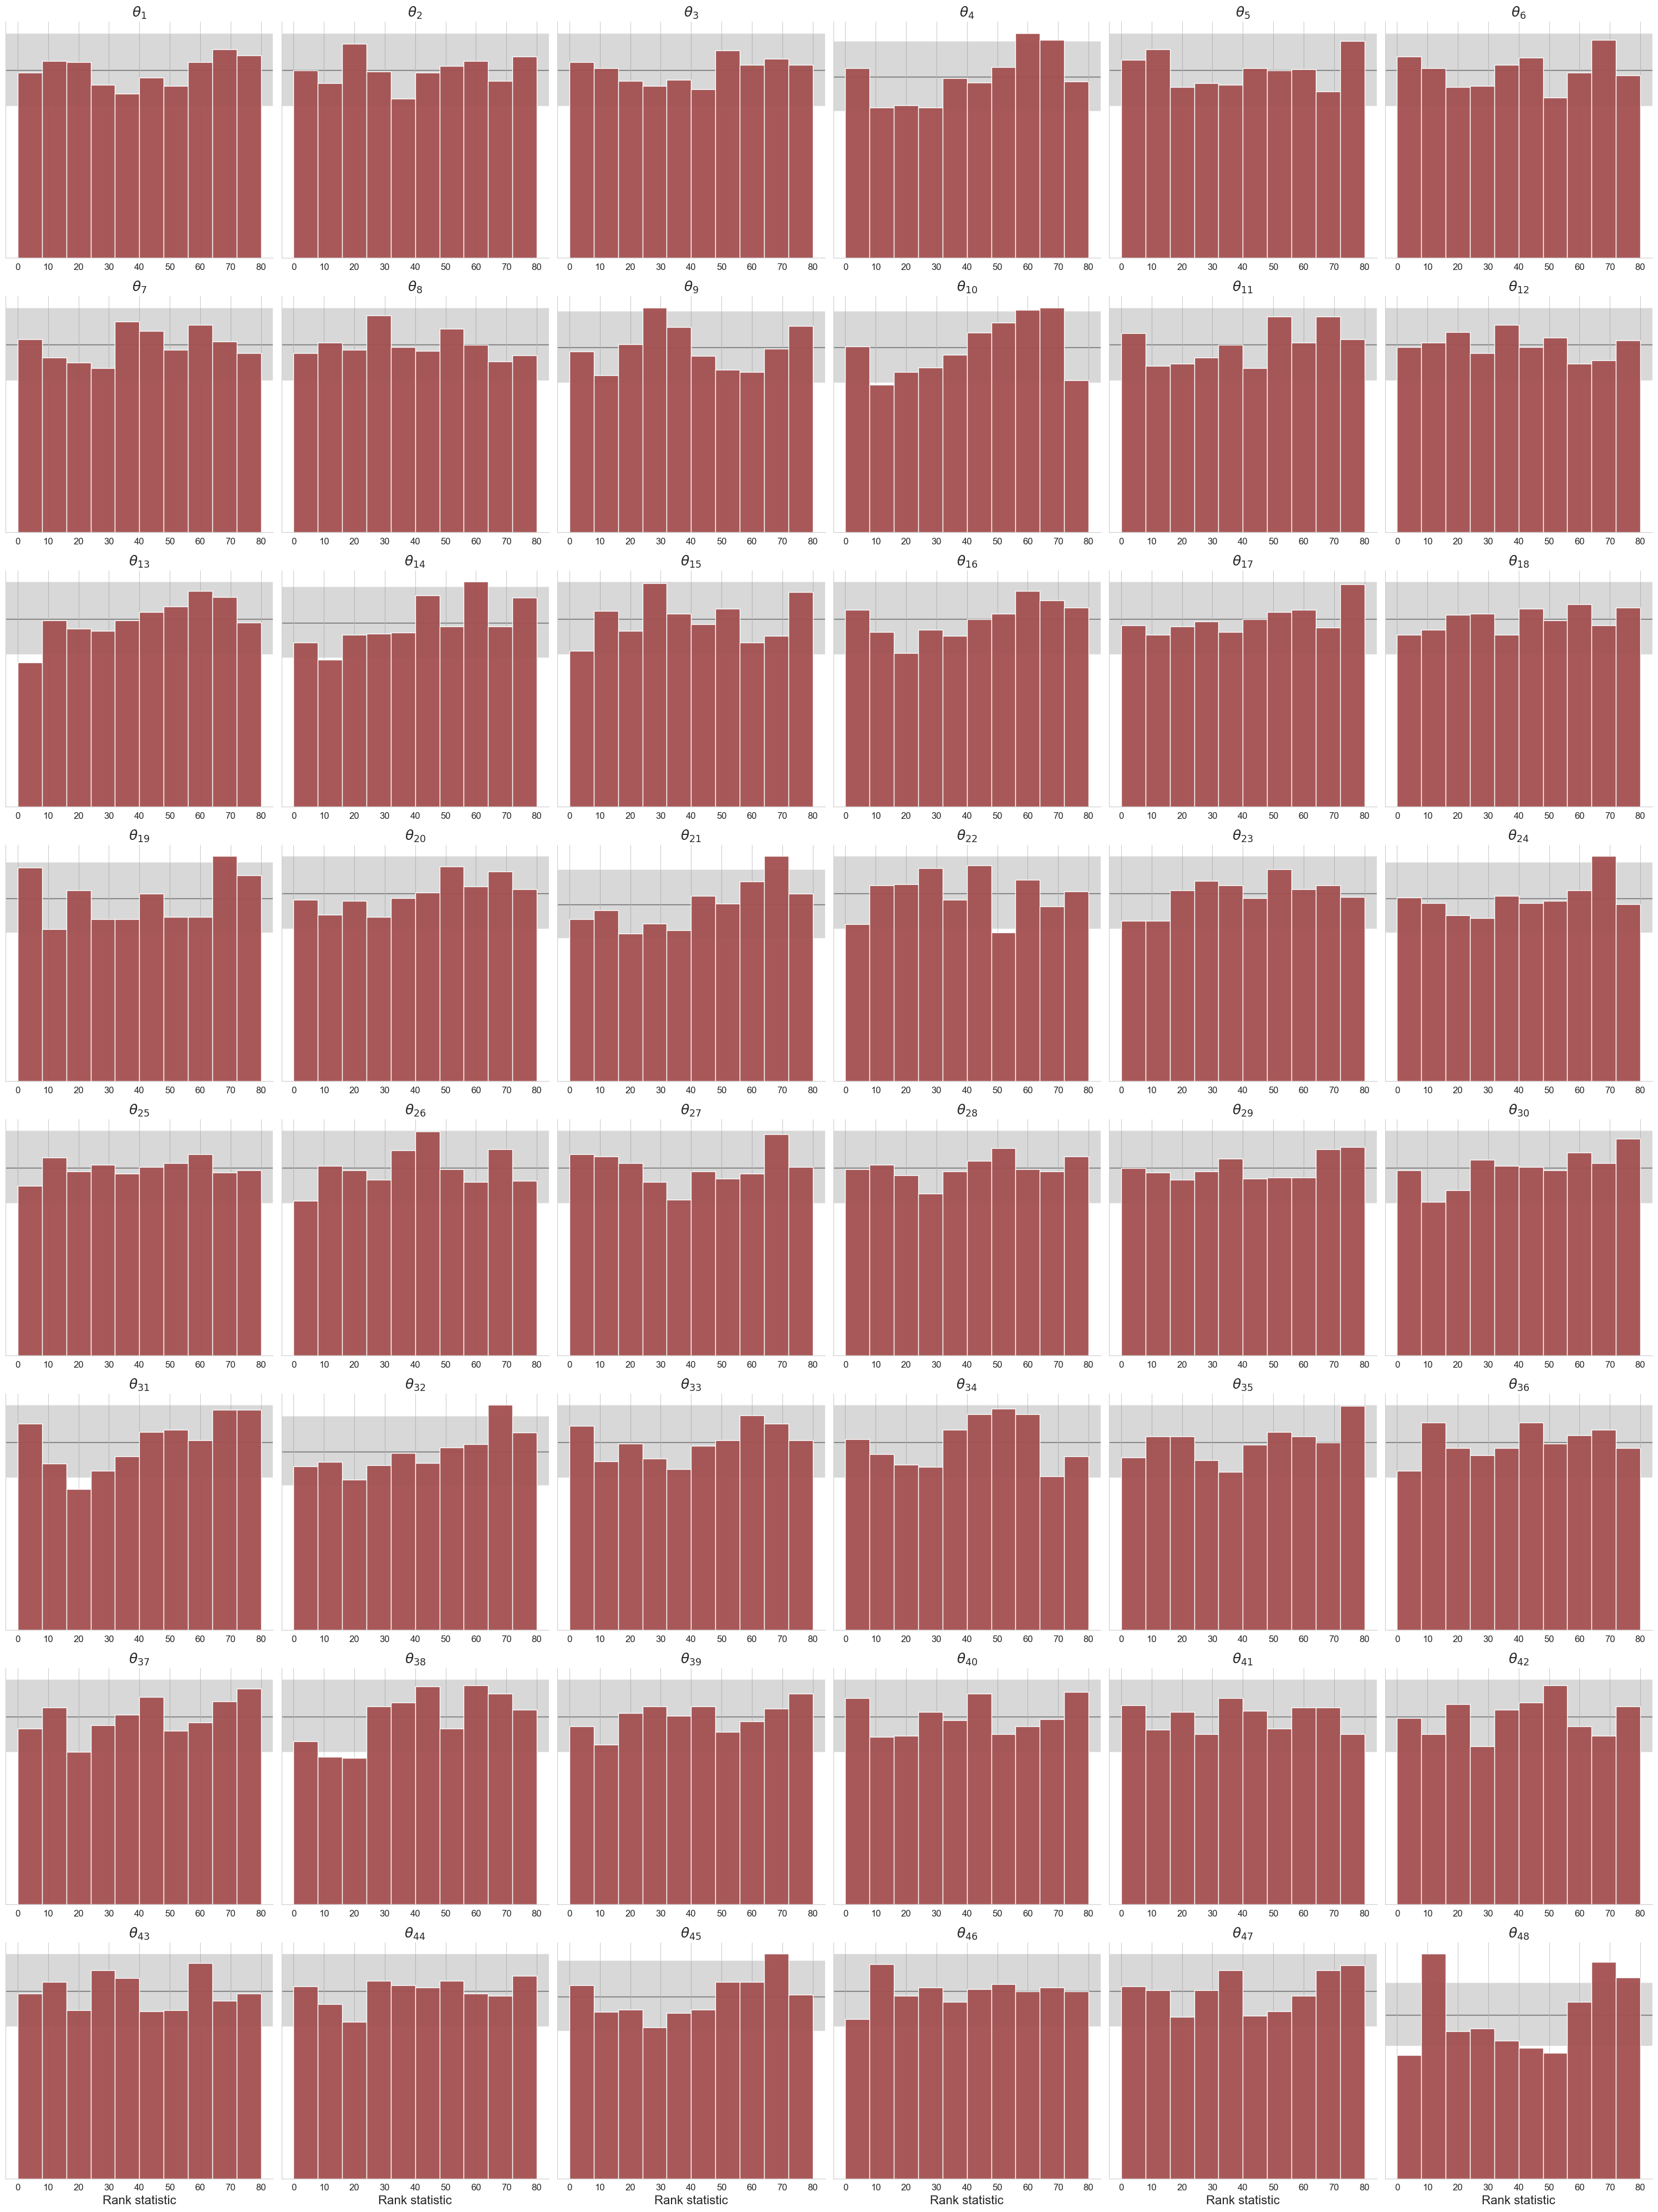

In [14]:
fig = trainer.diagnose_sbc_histograms()

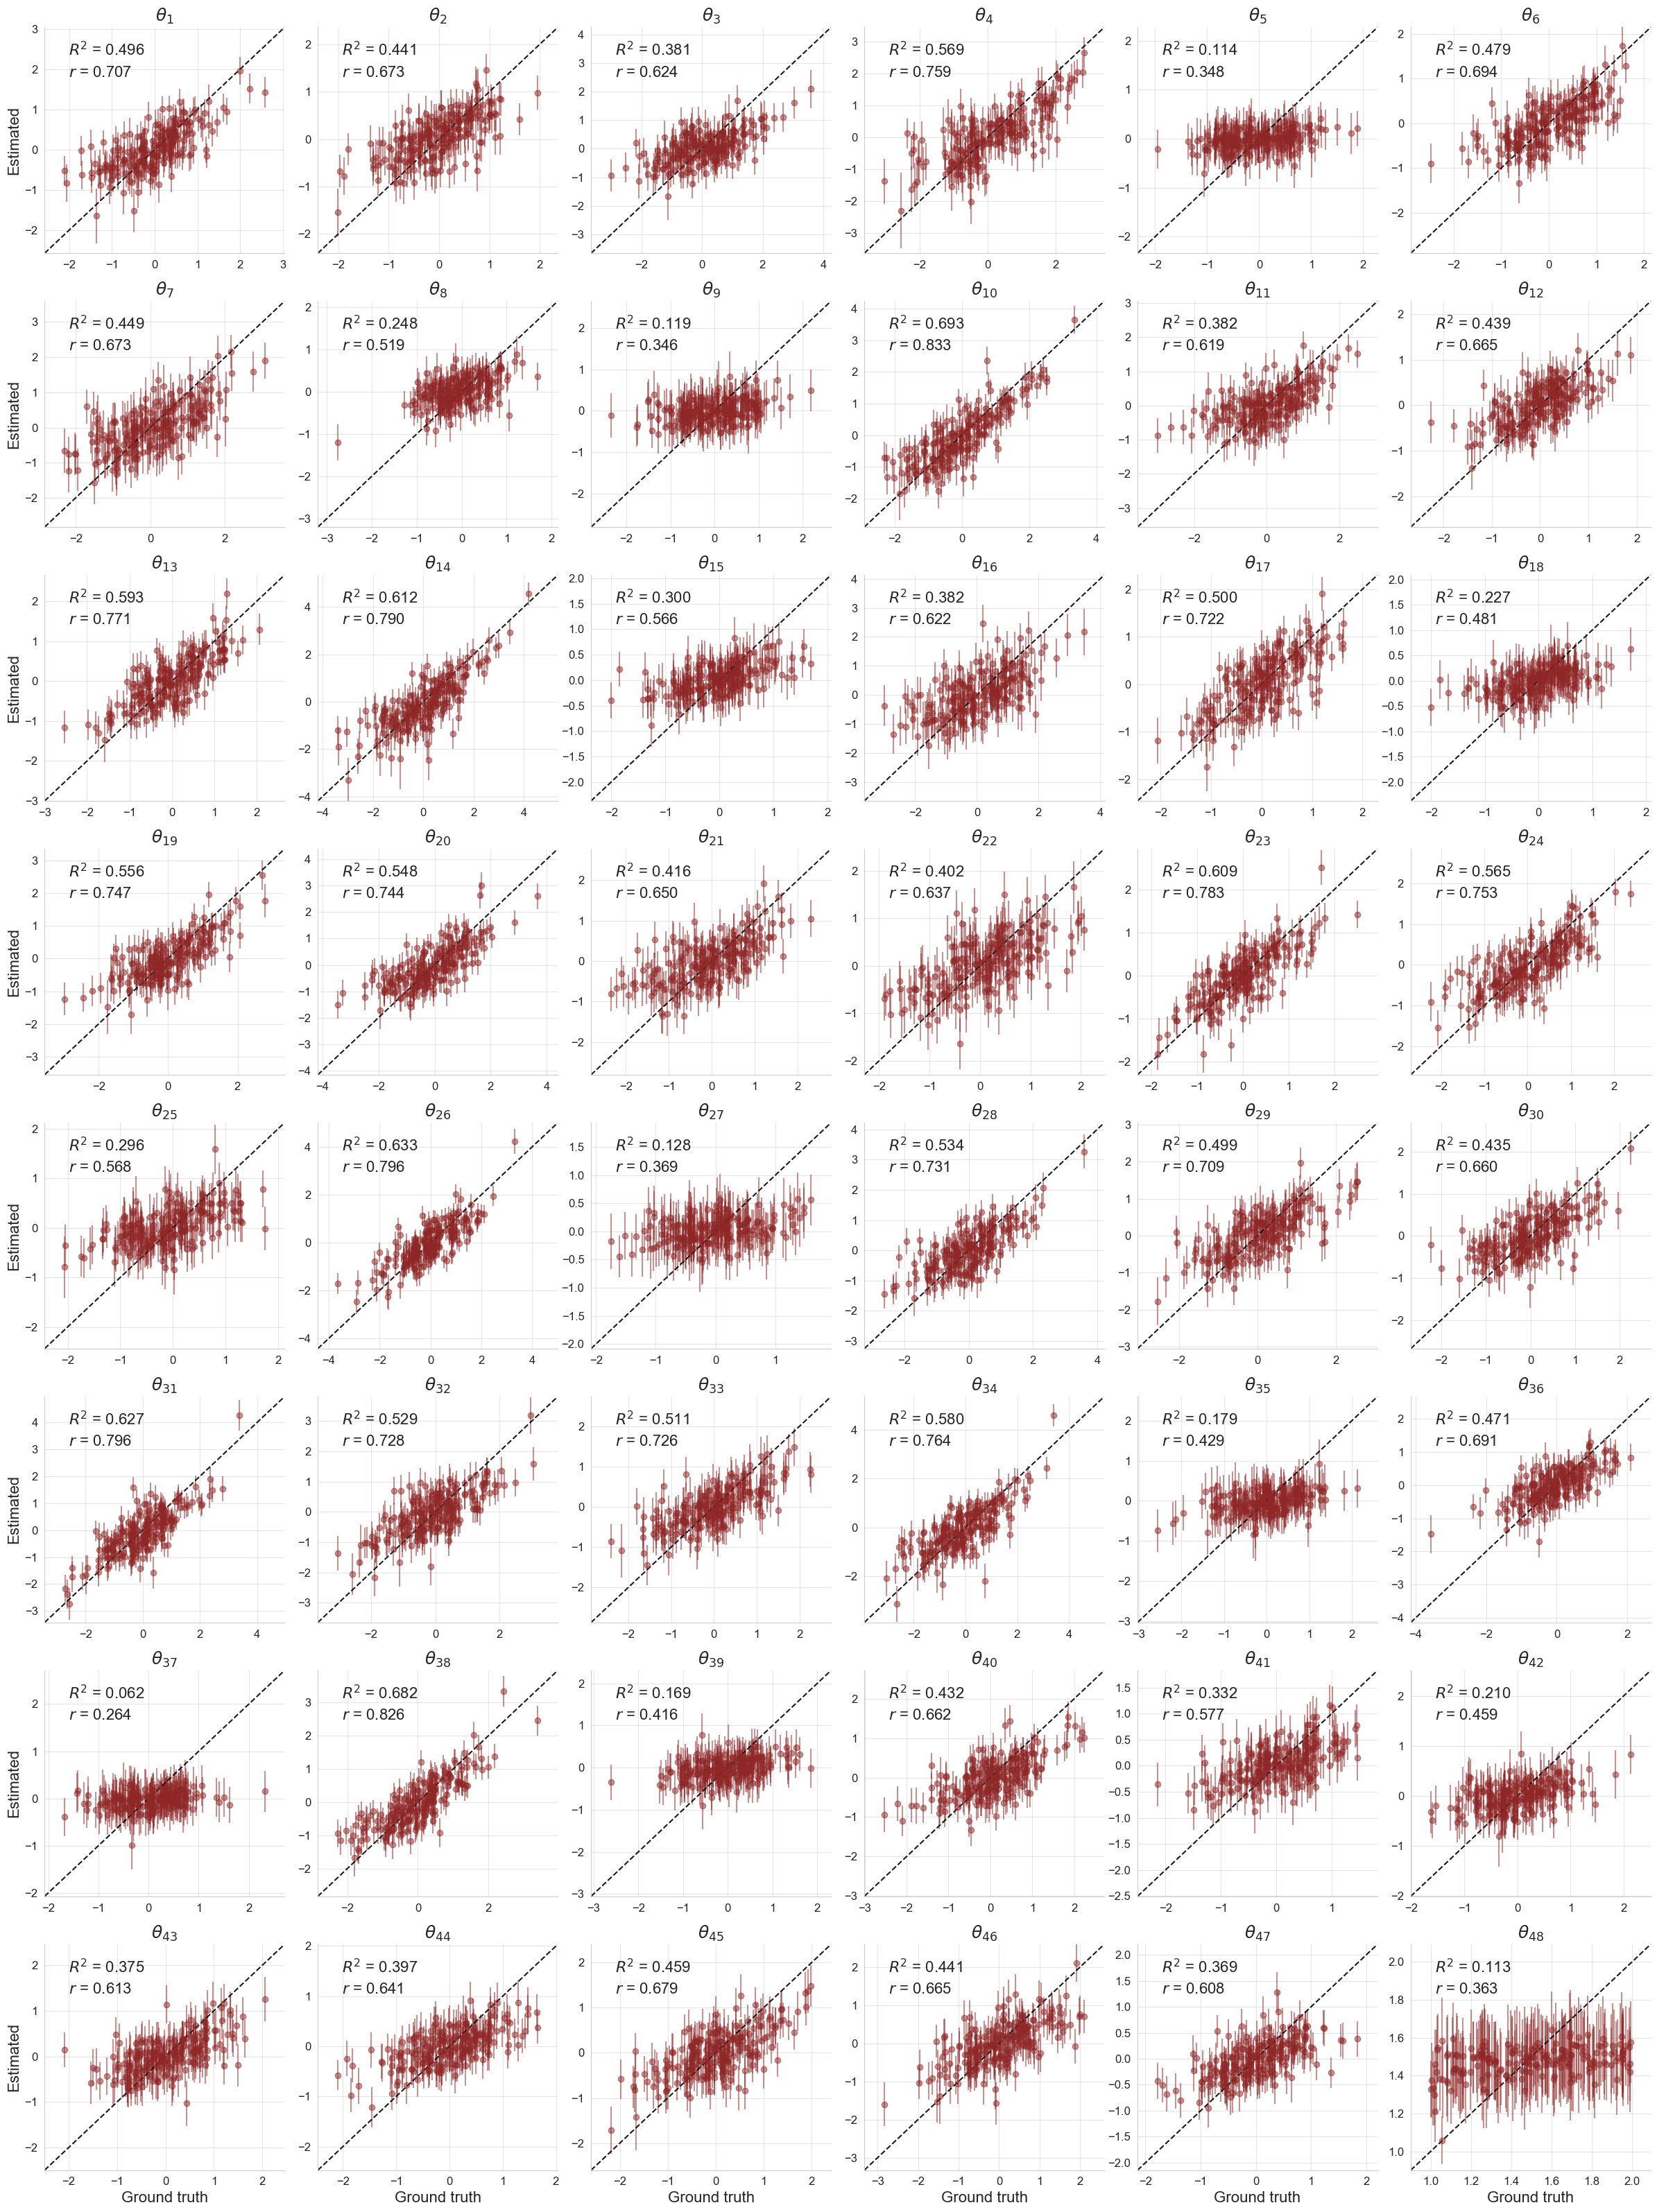

In [15]:
new_sims = trainer.configurator(trainer.generative_model(200))
posterior_draws = amortizer.sample(new_sims, n_samples=500)
fig = bf.diagnostics.plot_recovery(posterior_draws, new_sims["parameters"])

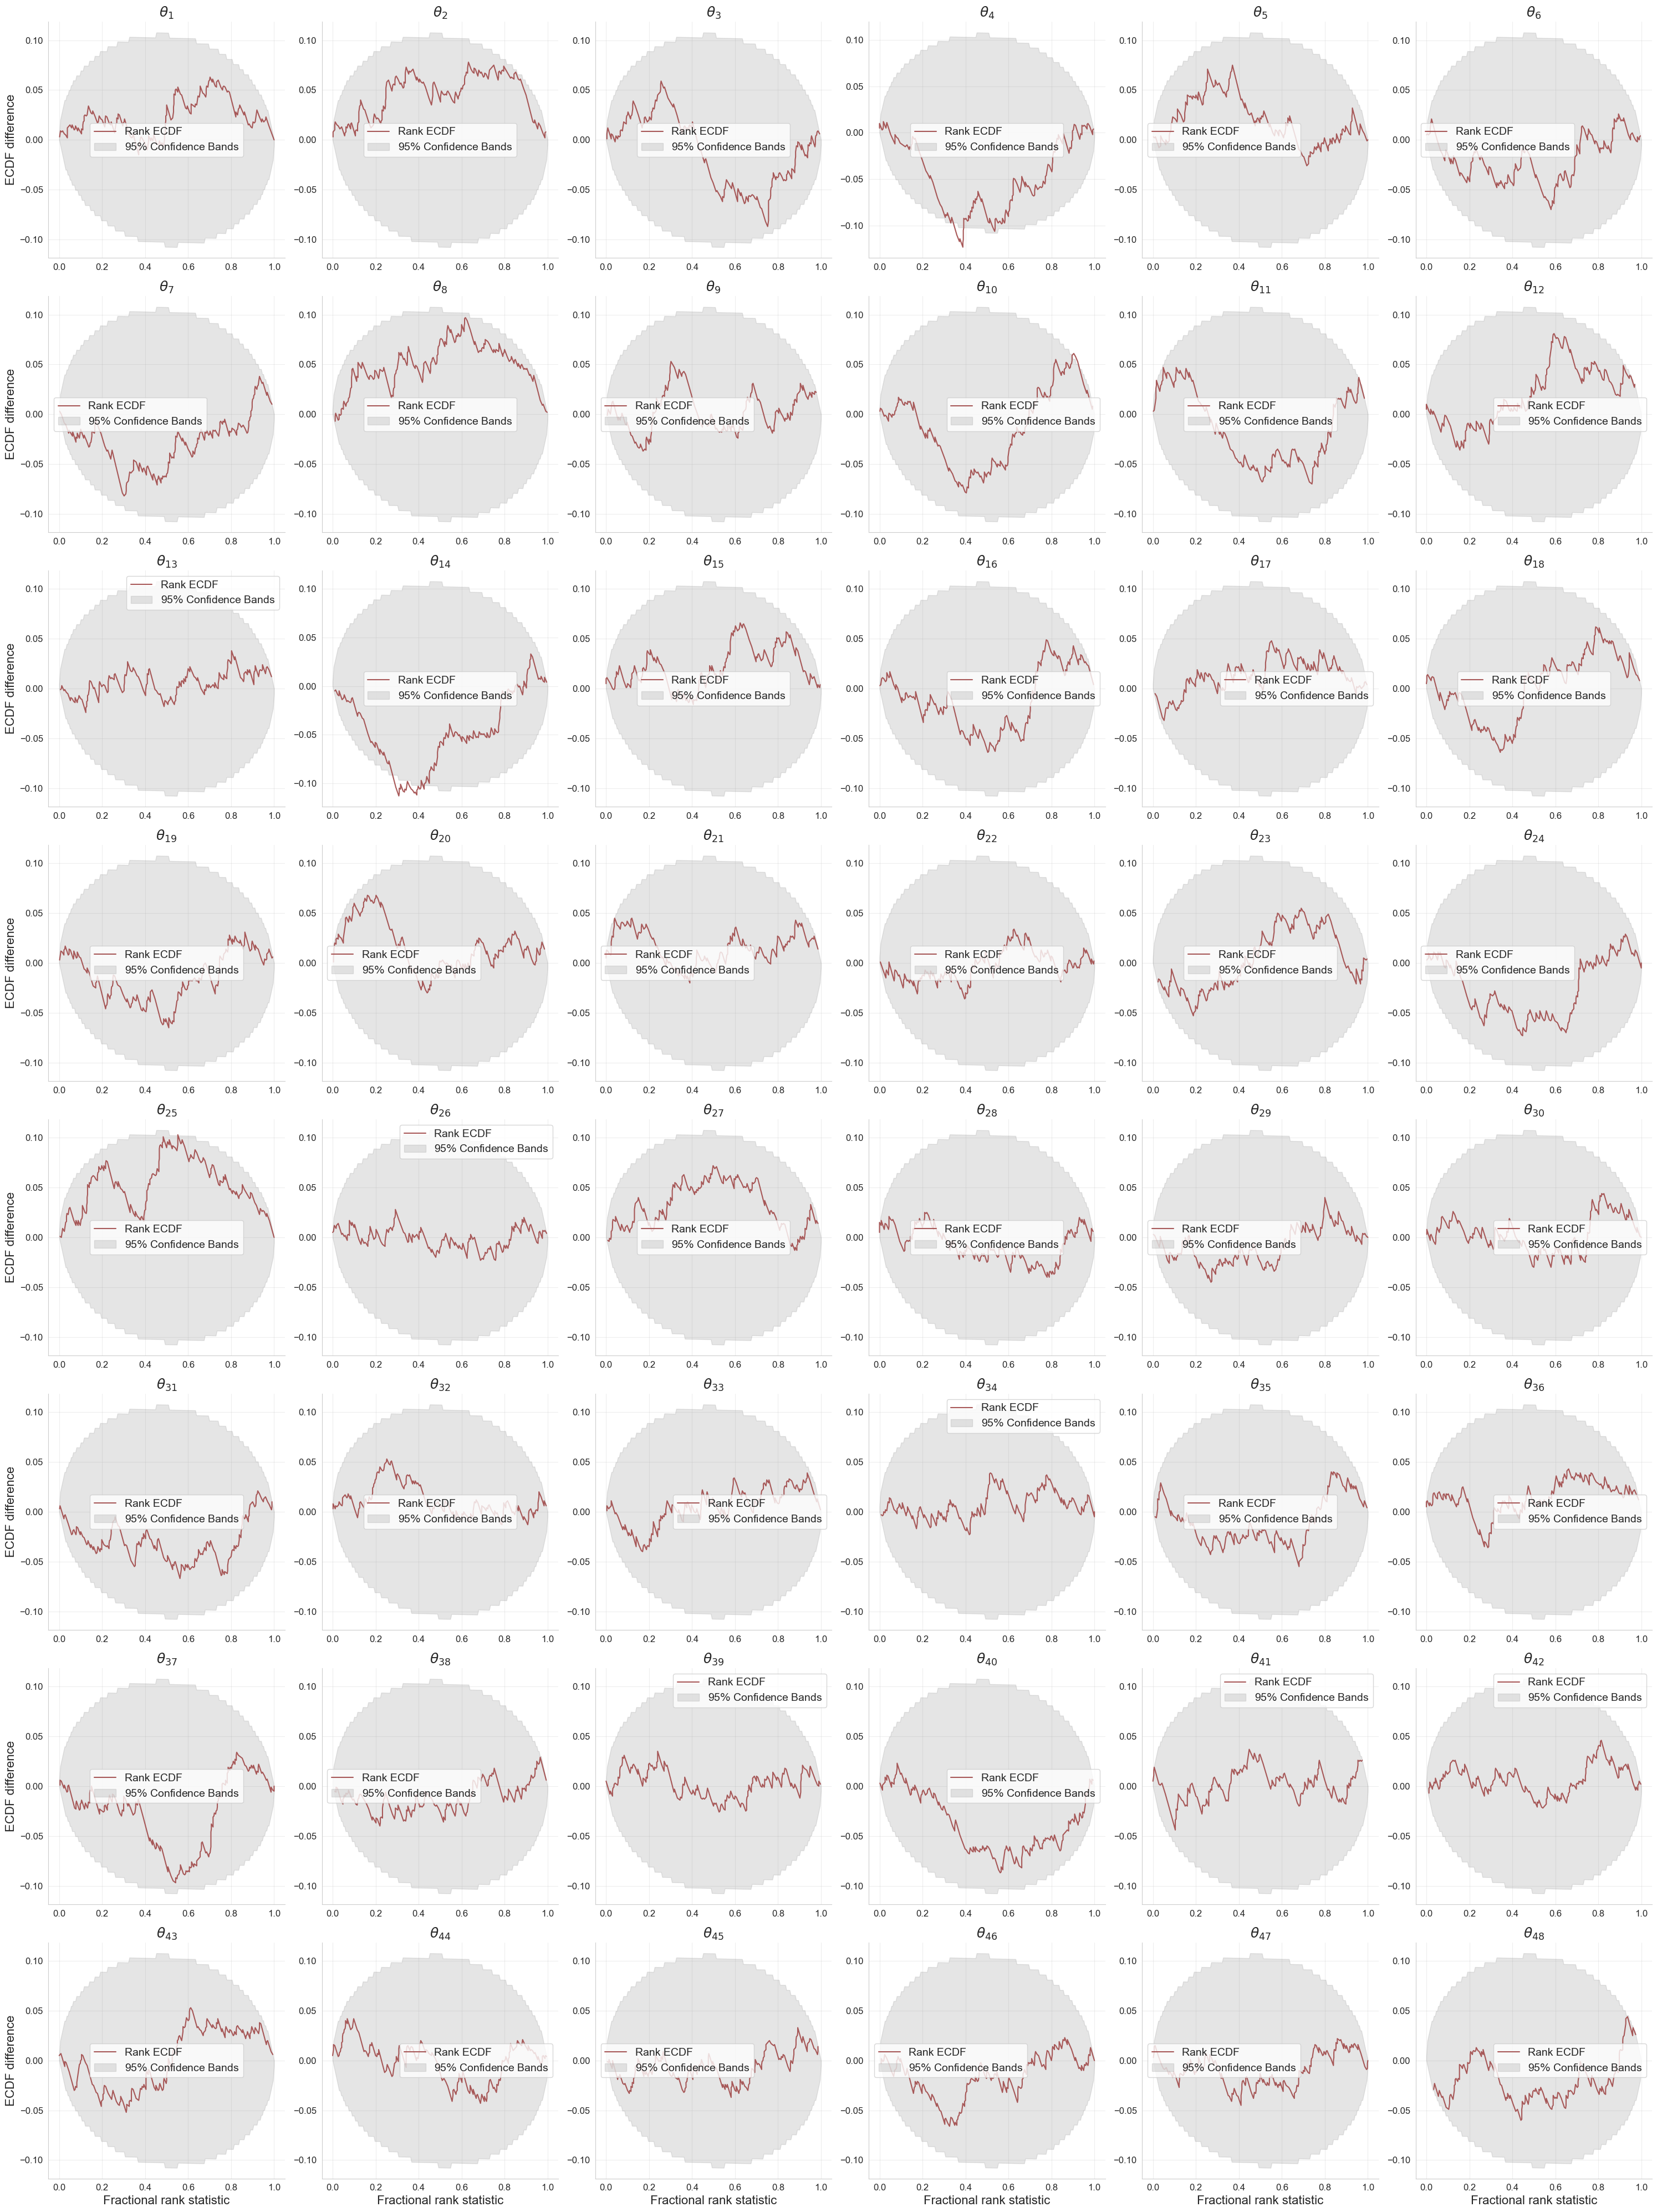

In [16]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_draws, new_sims["parameters"], difference=True)